# Module 2 — Colorectal Cancer HIPEC Agents: Patient Population

**Prerequisite:** Run `01_hipec_explore.ipynb` first to create the `oxaliplatin_analysis` and `mitomycin_analysis` tables.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1: Age Distribution by Sex

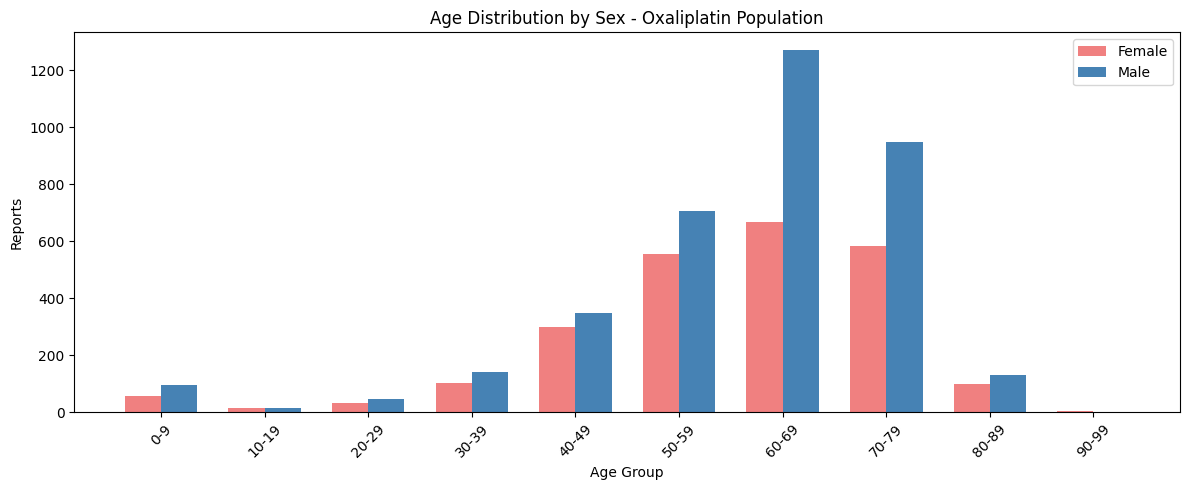

In [2]:
# Pull age and sex for oxaliplatin population
oxa_age_sex = pd.read_sql_query("""
    SELECT DISTINCT o.primaryid, d.age, d.sex
    FROM oxaliplatin_analysis o
    JOIN demo d ON o.primaryid = d.primaryid
    WHERE d.sex IN ('M', 'F')
      AND d.age IS NOT NULL
""", conn)

oxa_age_sex['age'] = pd.to_numeric(oxa_age_sex['age'], errors='coerce')
oxa_age_sex = oxa_age_sex.dropna(subset=['age'])

bins = range(0, 101, 10)
labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
oxa_age_sex['age_group'] = pd.cut(oxa_age_sex['age'], bins=bins, right=False, labels=labels)

oxa_age_counts = oxa_age_sex.groupby(['age_group', 'sex'], observed=True).size().unstack(fill_value=0)

x = np.arange(len(oxa_age_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, oxa_age_counts.get('F', 0), width, label='Female', color='lightcoral')
ax.bar(x + width/2, oxa_age_counts.get('M', 0), width, label='Male', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(oxa_age_counts.index.astype(str), rotation=45)
ax.set_xlabel('Age Group')
ax.set_ylabel('Reports')
ax.set_title('Age Distribution by Sex - Oxaliplatin Population')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2: Sex Breakdown

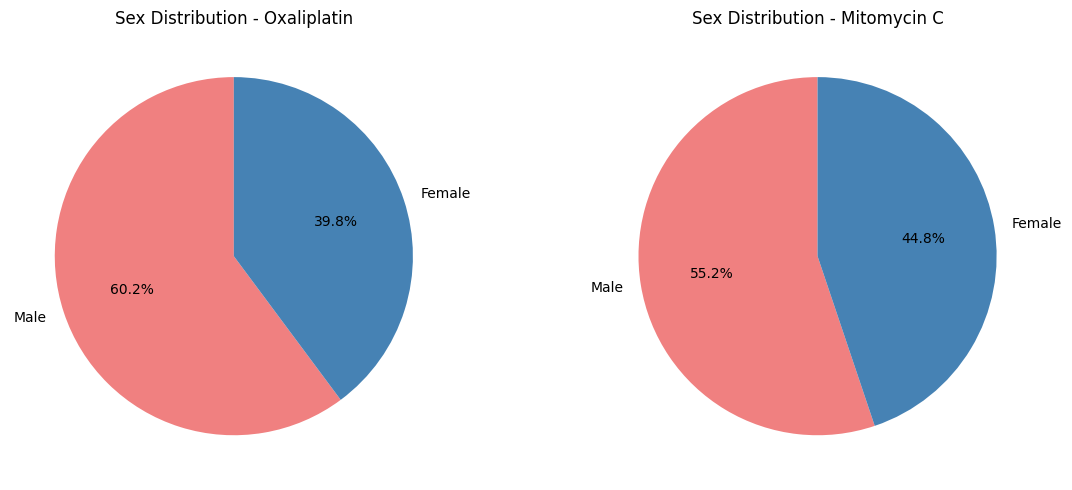

In [3]:
# Sex breakdown pie charts for both drugs side by side
oxa_sex = pd.read_sql_query("""
    SELECT DISTINCT o.primaryid, d.sex
    FROM oxaliplatin_analysis o
    JOIN demo d ON o.primaryid = d.primaryid
    WHERE d.sex IN ('M', 'F')
""", conn)

mmc_sex = pd.read_sql_query("""
    SELECT DISTINCT m.primaryid, d.sex
    FROM mitomycin_analysis m
    JOIN demo d ON m.primaryid = d.primaryid
    WHERE d.sex IN ('M', 'F')
""", conn)

sex_labels = {'M': 'Male', 'F': 'Female'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

oxa_counts = oxa_sex['sex'].value_counts()
ax1.pie(oxa_counts.values, labels=[sex_labels[s] for s in oxa_counts.index],
        autopct='%1.1f%%', colors=['lightcoral', 'steelblue'], startangle=90)
ax1.set_title('Sex Distribution - Oxaliplatin')

mmc_counts = mmc_sex['sex'].value_counts()
ax2.pie(mmc_counts.values, labels=[sex_labels[s] for s in mmc_counts.index],
        autopct='%1.1f%%', colors=['lightcoral', 'steelblue'], startangle=90)
ax2.set_title('Sex Distribution - Mitomycin C')

plt.tight_layout()
plt.show()

## Step 3: Top Reporting Countries

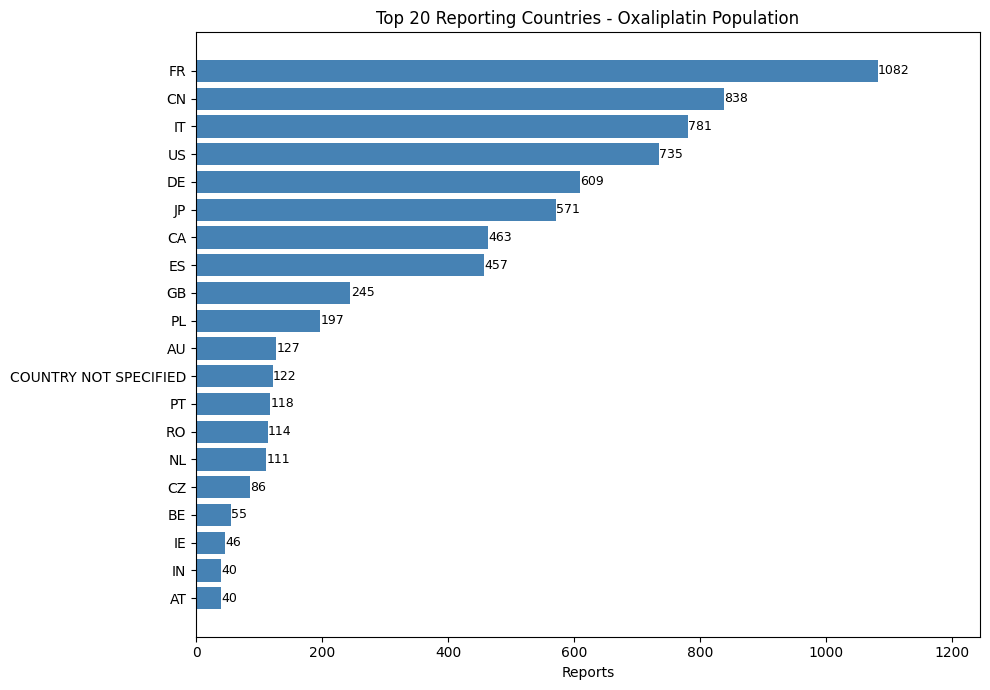

In [4]:
# Top reporting countries for oxaliplatin
oxa_countries = pd.read_sql_query("""
    SELECT DISTINCT o.primaryid, d.reporter_country
    FROM oxaliplatin_analysis o
    JOIN demo d ON o.primaryid = d.primaryid
    WHERE d.reporter_country IS NOT NULL
""", conn)

top_countries = (
    oxa_countries['reporter_country']
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_countries.index, top_countries.values, color='steelblue')

for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Reports')
ax.set_title('Top 20 Reporting Countries - Oxaliplatin Population')
ax.set_xlim(0, top_countries.values.max() * 1.15)
plt.tight_layout()
plt.show()